### Import libraries

In [1]:
import tensorflow as tf
import pathlib
import matplotlib.pyplot as plt
import os
import PIL
from PIL import Image
import numpy as np

### Download dataset (Tensorflow Flowers)

In this step, we download a flower image dataset using TensorFlow utilities.

We use a direct URL and the function `tf.keras.utils.get_file()` to:
- Download the dataset
- Extract it automatically (untar=True)
- Store it locally

The dataset is saved in a default directory (`~/.keras/datasets/`), and we store its path in `data_dir`.


In [2]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
archive = tf.keras.utils.get_file(
    origin = dataset_url,
    fname = "flower_photos",
    untar=True
)
data_dir = pathlib.Path(archive)
data_dir = data_dir / "flower_photos"
print(data_dir)

/Users/laylagalib/.keras/datasets/flower_photos/flower_photos


### Check if it worked

In [3]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print("Total images:",image_count)

Total images: 3670


In [4]:
print([item.name for item in data_dir.iterdir()])

['roses', 'sunflowers', 'daisy', 'dandelion', 'tulips', 'LICENSE.txt']


Number of rose images: 641


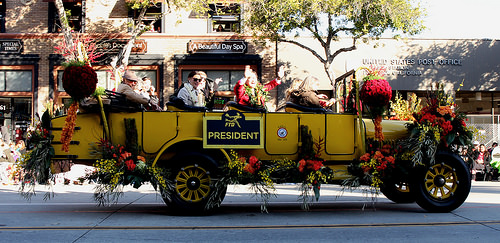

In [5]:
roses = list(data_dir.glob("roses/*"))
print("Number of rose images:", len(roses))

Image.open(str(roses[0]))

### Load Dataset

We use `tf.keras.utils.image_dataset_from_directory()` to load the dataset.

This function:
- Reads images from the directory
- Automatically assigns labels based on folder names
- Converts images into tensors
- Batches the data for efficient processing

We also:
- Resize all images to (150, 150)
- Use a batch size of 32

We split the dataset into:
- Training set (80%)
- Validation set (20%)

This is done using:
validation_split=0.2

The training set is used to train the model, while the validation set is used to evaluate performance and detect overfitting.

The `seed=42` ensures that the split is consistent across runs.

In [6]:
img_size = (150, 150) # 150x150 pixels, 
batch_size = 32 # is used in 1 step

train_ds = tf.keras.utils.image_dataset_from_directory( 
    data_dir, 
    validation_split=0.2, 
    subset="training", 
    seed=42, 
    image_size=img_size, 
    batch_size=batch_size 
)

val_ds = tf.keras.utils.image_dataset_from_directory( 
    data_dir, 
    validation_split=0.2, 
    subset="validation", 
    seed=42, 
    image_size=img_size, 
    batch_size=batch_size 
)


Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [7]:
class_names = train_ds.class_names
print(class_names)

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


### Visualise Data

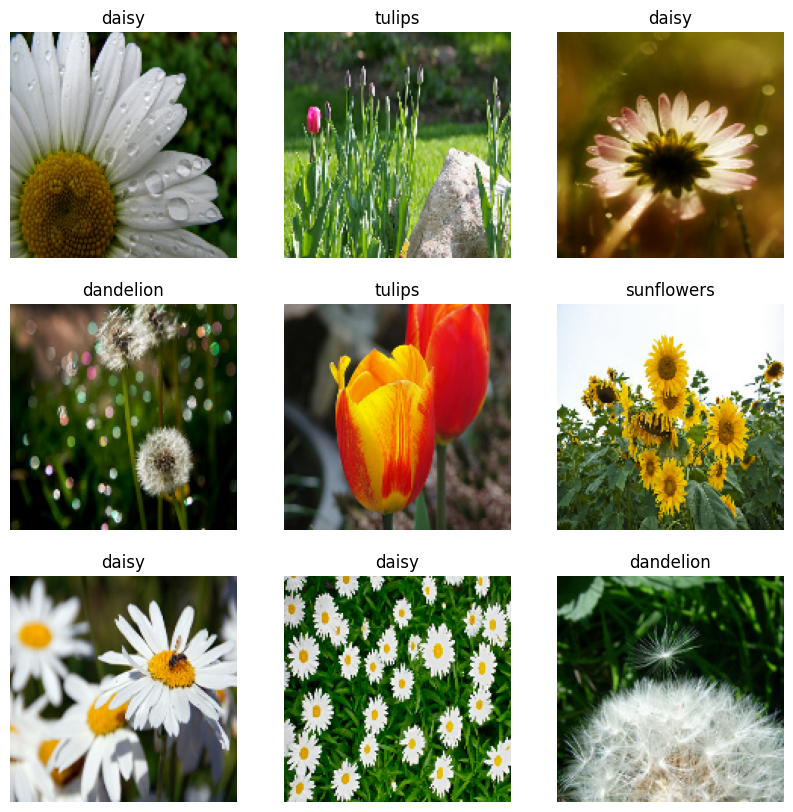

In [8]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [9]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 150, 150, 3)
(32,)


### Standardise the data

The original pixel values of the image are [0, 255]. 

Neural Networks perform better when inputs are scaled to a smaller range, so we normalise pixel values to [0, 1].

We use:
`tf.keras.layers.Rescaling(1./255)`

This divides every pixel value by 255.

We apply this transformation to the dataset using `.map()`, which processes each batch of images.

In [10]:
normalisation_layer = tf.keras.layers.Rescaling(1./255)

In [11]:
normalised_ds = train_ds.map(lambda x, y: (normalisation_layer(x), y))
image_batch, labels_batch = next(iter(normalised_ds))
first_image = image_batch[0]

### Verifying Normalisation

To confirm normalisation worked, we:
- Extract one batch of images
- Select a single image
- Check its minimum and maximum pixel values

After normalisation, values should lie between 0.0 and 1.0 instead of 0 and 255.

In [12]:
print(np.min(first_image), np.max(first_image))

0.01688315 1.0


## CNN Layer Explanation
### Rescaling Layer
The `Rescaling(1./255)` layer normalizes image pixel values from the range `[0, 255]` to `[0, 1]`.

This helps the neural network train more efficiently.

### Conv2D Layers
The `Conv2D` layers detect visual patterns in the images.

Early convolution layers may learn simple features such as edges and colors, while deeper convolution layers can learn more complex patterns such as petals and flower shapes.

### MaxPooling2D Layers
The `MaxPooling2D` layers reduce the size of the feature maps while keeping the most important information.

This helps reduce computation and makes the model focus on strong visual features.

### Flatten Layer
The `Flatten` layer converts the 2D feature maps into a 1D vector.

This prepares the extracted features for the final classification layers.

### Dense Layers
The `Dense` layers use the extracted features to make the final prediction.

The last Dense layer has one output for each flower class.

In [13]:
num_classes = len(class_names)

model = tf.keras.Sequential([
    tf.keras.Input(shape=(150, 150, 3)),

    tf.keras.layers.Rescaling(1./22),

    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPool2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPool2D(),

    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.MaxPool2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(num_classes)
])

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,997 (18.42 MB)

 Trainable params: 4,828,997 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

## Compiling the Model

Before training, the model needs to be compiled.

Compiling defines how the model will learn and how performance will be measured.

We specify:

### Optimizer: Adam
Adam is an optimizer that adjusts the model's weights during training.

It helps the model gradually improve its predictions.

### Loss Function
`SparseCategoricalCrossentropy` is used because this is a multi-class classification problem.

We use `from_logits=True` because the final Dense layer outputs raw scores instead of probabilities.

### Accuracy
Accuracy shows the percentage of images the model classifies correctly.

In [15]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

## Training the Model

During training, the model looks at the training images multiple times.

Each full pass through the training dataset is called an **epoch**.

For each epoch, the model:
- Makes predictions
- Calculates the loss
- Updates its weights
- Measures accuracy on both training and validation data

The validation accuracy helps us understand how well the model performs on unseen data.

In [16]:
epochs = 10

history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs=epochs
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 71s 722ms/step - accuracy: 0.4343 - loss: 2.5746 - val_accuracy: 0.5627 - val_loss: 1.0825
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 51s 550ms/step - accuracy: 0.6042 - loss: 1.0050 - val_accuracy: 0.6076 - val_loss: 1.0253
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 47s 507ms/step - accuracy: 0.6802 - loss: 0.8002 - val_accuracy: 0.5872 - val_loss: 1.0824
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 84s 914ms/step - accuracy: 0.7793 - loss: 0.5855 - val_accuracy: 0.5940 - val_loss: 1.3738
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 42s 457ms/step - accuracy: 0.8236 - loss: 0.5090 - val_accuracy: 0.6172 - val_loss: 1.5602
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 45s 489ms/step - accuracy: 0.8614 - loss: 0.3957 - val_accuracy: 0.6063 - val_loss: 1.7620
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 62s 673ms/step - accuracy: 0.9118 - loss: 0.2553 - val_accuracy: 0.5831 - val_loss: 2.4974
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 46s 497ms/step - accuracy: 0.9496 - loss: 0.1558 - val_accu

### Visualising Training Results

After training, we plot the model's accuracy and loss over each epoch.

These plots help us understand:
- whether the model is learning
- whether the model is overfitting
- how training performance compares to validation performance

If training accuracy improves but validation accuracy stays low or gets worse, this may indicate overfitting.

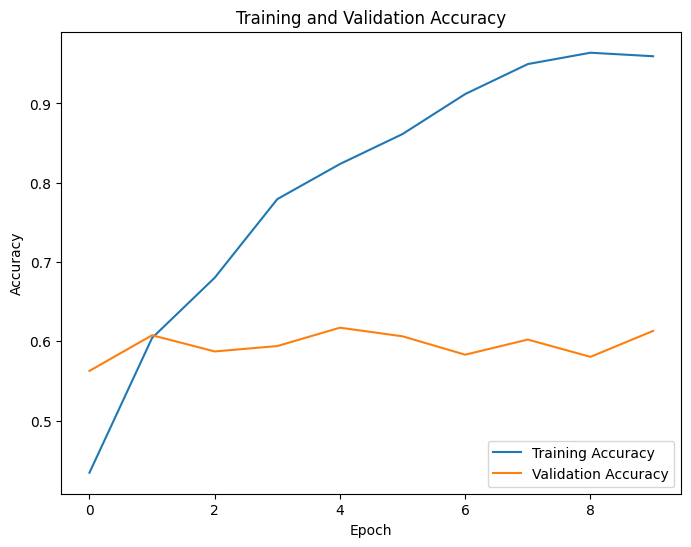

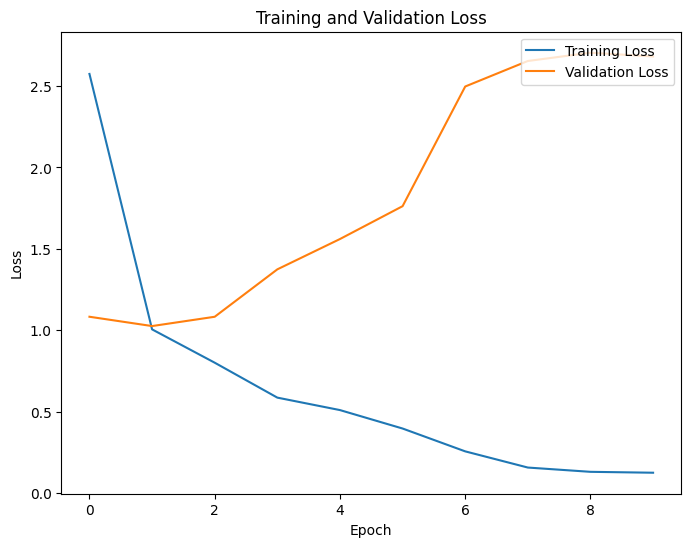

In [18]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 6))
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()